In [4]:
import sys
import os 
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import itertools
import pickle
from mpl_toolkits.axes_grid1 import make_axes_locatable
os.chdir("/home/adityamoger/Documents/GitHub/dynamic_model_of_cocktail_party_nightmare/")

sys.path.append("./exploratory_analysis/")
sys.path.append("./dynamic_model/")
from snr_implementation import given_sound_objects_return_detected_sounds


from read_simulation_output import read_data_per_simulation_per_bat
from snr_implementation import given_sound_objects_return_detected_sounds
from supporting_files.utilities import make_dir

import bisect
plt.style.use("dark_background")

# Markovian process
assuming the detections come from some markoving generating process, lets try to learn the parameters of this markovian process.

### base case
1. the model is simple with one set of emission and transmission matrices guiding the whole process. 
2. we assume these change  between bats, lets learn from time series of one bat and see how it is different for other bats maybe

### what is the markovian process even on
generates detection in one of the grid cells. if the predictions are consistent, then the transmission probabilities of the process will be high of the 1-1 case
- what is this 1 and 0? 1 is prescence of detection in the grid cell, 0 is absence. 1-1 refers to cases where the transmission happens from 1 state to 1 state. 
- trasmission matrix having high 0-0 means cells that are empty, stay empty for a lot higher time? cells that are empty are more likely to stay empty. 

## Formalize terms
So each grid cell will have a transmission matrix. Let's fix emission to 0.5 and 0.5 for 0 and 1 cuse start. but it is possible that its just 1 for 0 and 0 for 1 ngl. 
makes sense for now



In [ ]:
# make matrix doomer


In [9]:
def make_ordered_lists_of_params(array_of_parameter_lists):
    product_of_lists = list(itertools.product(*array_of_parameter_lists))
    return product_of_lists

def reformat_matrices(nan_matrix, track_unique_objects):
    
    nan_matrix = nan_matrix.T
    
    sorting_indices = np.argsort(track_unique_objects)
    nan_matrix = nan_matrix[sorting_indices]
    track_unique_objects = np.array(track_unique_objects)[sorting_indices]
    
    # nan_matrix = nan_matrix[:, ~np.isnan(nan_matrix).all(0)]
    masked_array = np.ma.array(nan_matrix, mask=np.isnan(nan_matrix))
    
    return nan_matrix, track_unique_objects, masked_array

In [12]:
#store extracted data into a dict
# key needs to be some structure such that the parameters for that can be extracted. maybe ill just make it ordered
NUM_BATS= 30
INCLUDE_DIRECT_SOUNDS_ARR = [True]
FOCAL_BATS = [1, 7, 17]
AZIMUTH_THRESHOLDS = [np.pi, np.pi/2, np.pi/6]

list_of_parameters = [FOCAL_BATS, INCLUDE_DIRECT_SOUNDS_ARR, AZIMUTH_THRESHOLDS]
ordered_list_of_parameters = make_ordered_lists_of_params(list_of_parameters)
labels_of_parameters = ["focal_bat", "include_direct_sounds", "azimuth_thresholds"]
ordered_list_of_parameters

[(1, True, 3.141592653589793),
 (1, True, 1.5707963267948966),
 (1, True, 0.5235987755982988),
 (7, True, 3.141592653589793),
 (7, True, 1.5707963267948966),
 (7, True, 0.5235987755982988),
 (17, True, 3.141592653589793),
 (17, True, 1.5707963267948966),
 (17, True, 0.5235987755982988)]

In [13]:

with open(f'/media/adityamoger/T7 Shield/consistency_of_calls/no_call_directionality/DATA_effect_of_group_size/{NUM_BATS}/heard_sounds_data.pkl', 'rb') as fp:
    dictionary_to_store_heard_sounds = pickle.load(fp)

In [105]:

ANGULAR_RESOLUTION = np.pi/6 # radians
RADIAL_RESOLUTION = 0.002 #in seconds

def convert_into_grids(heard_sounds_array, param):
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    grid_labels= ["self_echoes", "direct_calls", "non_self_echoes"]
    
    spatial_grid_r = np.arange(0.005,0.035,RADIAL_RESOLUTION)
    spatial_grid_theta = np.arange(-np.pi, np.pi, ANGULAR_RESOLUTION)
    matrix_spatial_grid = np.zeros(shape=(len(spatial_grid_r), len(spatial_grid_theta)))
    
    counter=0
    store_grids = [matrix_spatial_grid.copy(), matrix_spatial_grid.copy(), matrix_spatial_grid.copy(), matrix_spatial_grid.copy()]
    for i, frame_heard_sounds in enumerate(heard_sounds_array):
        # store_grids = [matrix_spatial_grid.copy()]*3
        for sound_object in frame_heard_sounds:
            
            delta_t = np.array(sound_object["occurance_times"])[0] - sound_object["bat_last_call_time"]
            theta = sound_object["bat_direction"].angle_between(
                sound_object["incident_direction"]
            )
            
            
            grid_row_index = bisect.bisect_right(spatial_grid_r, delta_t) -1
            grid_column_index = bisect.bisect_right(spatial_grid_theta, theta) -1
            # print(FOCAL_BAT, sound_object["emitter_id"])
            if sound_object["emitter_id"] == FOCAL_BAT:
                
                index_for_storage = 0
                counter+=1
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "direct":
                index_for_storage = 1
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "echo":
                index_for_storage = 2
            # print(grid_row_index, grid_column_index)
            # if theta>-np.pi and theta<-5*np.pi/6:
            #     print(theta)
            store_grids[index_for_storage][grid_row_index, grid_column_index] +=1
            
    print(counter)   
    store_grids[3] = np.sum(store_grids[0:3], axis=0)
    return store_grids, spatial_grid_r, spatial_grid_theta

def convert_into_grids_time_series(heard_sounds_array, param):
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    grid_labels= ["self_echoes", "direct_calls", "non_self_echoes"]
    
    spatial_grid_r = np.arange(0.005,0.035,RADIAL_RESOLUTION)
    spatial_grid_theta = np.arange(-np.pi, np.pi, ANGULAR_RESOLUTION)
    matrix_spatial_grid = np.zeros(shape=(len(spatial_grid_r), len(spatial_grid_theta)))
    
    store_grid_time_series = []
    counter=0
    for i, frame_heard_sounds in enumerate(heard_sounds_array):
        # store_grids = [matrix_spatial_grid.copy()]*3
        store_grids = [matrix_spatial_grid.copy(), matrix_spatial_grid.copy(), matrix_spatial_grid.copy(), matrix_spatial_grid.copy()]
        for sound_object in frame_heard_sounds:
            
            delta_t = np.array(sound_object["occurance_times"])[0] - sound_object["bat_last_call_time"]
            theta = sound_object["bat_direction"].angle_between(
                sound_object["incident_direction"]
            )
            
            
            grid_row_index = bisect.bisect_right(spatial_grid_r, delta_t) -1
            grid_column_index = bisect.bisect_right(spatial_grid_theta, theta) -1
            
            if sound_object["emitter_id"] == FOCAL_BAT:
                index_for_storage = 0
                counter+=1
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "direct":
                index_for_storage = 1
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "echo":
                index_for_storage = 2
            # print(grid_row_index, grid_column_index)
            # if theta>-np.pi and theta<-5*np.pi/6:
            #     print(theta)
            store_grids[index_for_storage][grid_row_index, grid_column_index] +=1
        store_grids[3] = np.sum(store_grids[0:3], axis=0)
        store_grid_time_series.append(store_grids)
    print(counter)
    return np.array(store_grid_time_series), spatial_grid_r, spatial_grid_theta

def convert_matrix_for_plotting_nicer(list_of_matrix, rows, columns, increase_resolution_by): #:( plot nice banane ke liye 
    angular_resolution = columns[1] - columns[0]
    new_angular_resolution = angular_resolution/increase_resolution_by
    new_column_labels = np.arange(-np.pi, np.pi, new_angular_resolution)
    
    # print(new_matrix.shape)
    new_list_of_matrix = []
    for matrix in list_of_matrix:
        new_matrix = np.zeros(shape=(len(rows), len(new_column_labels)-1)).copy()
        for i in range(new_matrix.shape[0]):
            for j in range(new_matrix.shape[1]):
                index_in_old_matrix = i, j//increase_resolution_by
                # print(index_in_old_matrix)
                new_matrix[i,j] = matrix[index_in_old_matrix]
        new_list_of_matrix.append(new_matrix)
    
    return new_list_of_matrix, new_angular_resolution

In [92]:
param = ordered_list_of_parameters[0]
heard_sounds_array = dictionary_to_store_heard_sounds[param]

trial_timeseries = convert_into_grids_time_series(heard_sounds_array, param)[0]
spatial_r, theta = convert_into_grids_time_series(heard_sounds_array, param)[1:]

529
529


In [114]:

def convert_timeseries_to_one_hot (timeseries):
    new_timeseries = []
    for i in timeseries:
        if i==0:
            new_timeseries.append(0)
        elif i>0:
            new_timeseries.append(1)
        else: 
            raise ValueError("Negative counts in matrix")
        
    return np.array(new_timeseries)


def compute_transition_matrix_given_cell_first_degree(timeseries_of_grid, position, which_type_of_sound, use_1_0):
    time_series_for_cell = timeseries_of_grid[:, which_type_of_sound, *position]
    if use_1_0:
        time_series_for_cell = convert_timeseries_to_one_hot(time_series_for_cell)    
    
    unique_entries = np.unique(time_series_for_cell)
    if len(unique_entries)==1:
        unique_entries = np.array([0,1])
        
    transition_matrix = np.zeros(shape=(len(unique_entries), len(unique_entries)))
    
    for i, current_state in enumerate(time_series_for_cell[1:]):
        previous_state = time_series_for_cell[i-1]
        row_index = np.where(unique_entries==previous_state)
        column_index = np.where(unique_entries==current_state)
        transition_matrix[row_index, column_index]+=1
    
    # normalize transition matrix
    # print(transition_matrix)
    row_sums = transition_matrix.sum(axis=0)
    
    transition_matrix = transition_matrix/row_sums[:, np.newaxis]
    return transition_matrix
            
            
compute_transition_matrix_given_cell_first_degree(trial_timeseries, (-1,0), 2, True)

def get_probabilities_for_grid_one_hot(grids_timeseries, which_transition_matrix_element):
    probabilities_for_all_sound_types = []
    for type_of_sound in range(len(grids_timeseries[0])):
        output_probabilities = np.zeros(shape=grids_timeseries[0, type_of_sound].shape)
        # timeseries_of_a_grid = grids_timeseries[:, which_type_of_sound]
        for i in range(output_probabilities.shape[0]):
            for j in range(output_probabilities.shape[1]):
                transition_matrix = compute_transition_matrix_given_cell_first_degree(grids_timeseries, (i,j), type_of_sound, True)
                # print(transition_matrix)
                output_probabilities[i,j] = transition_matrix[*which_transition_matrix_element]
                
        probabilities_for_all_sound_types.append(output_probabilities)
        
        
    return probabilities_for_all_sound_types


prob_grid_11= get_probabilities_for_grid_one_hot(trial_timeseries, (1,1))

/tmp/ipykernel_292870/3400566174.py:35: RuntimeWarning: invalid value encountered in divide
  transition_matrix = transition_matrix/row_sums[:, np.newaxis]


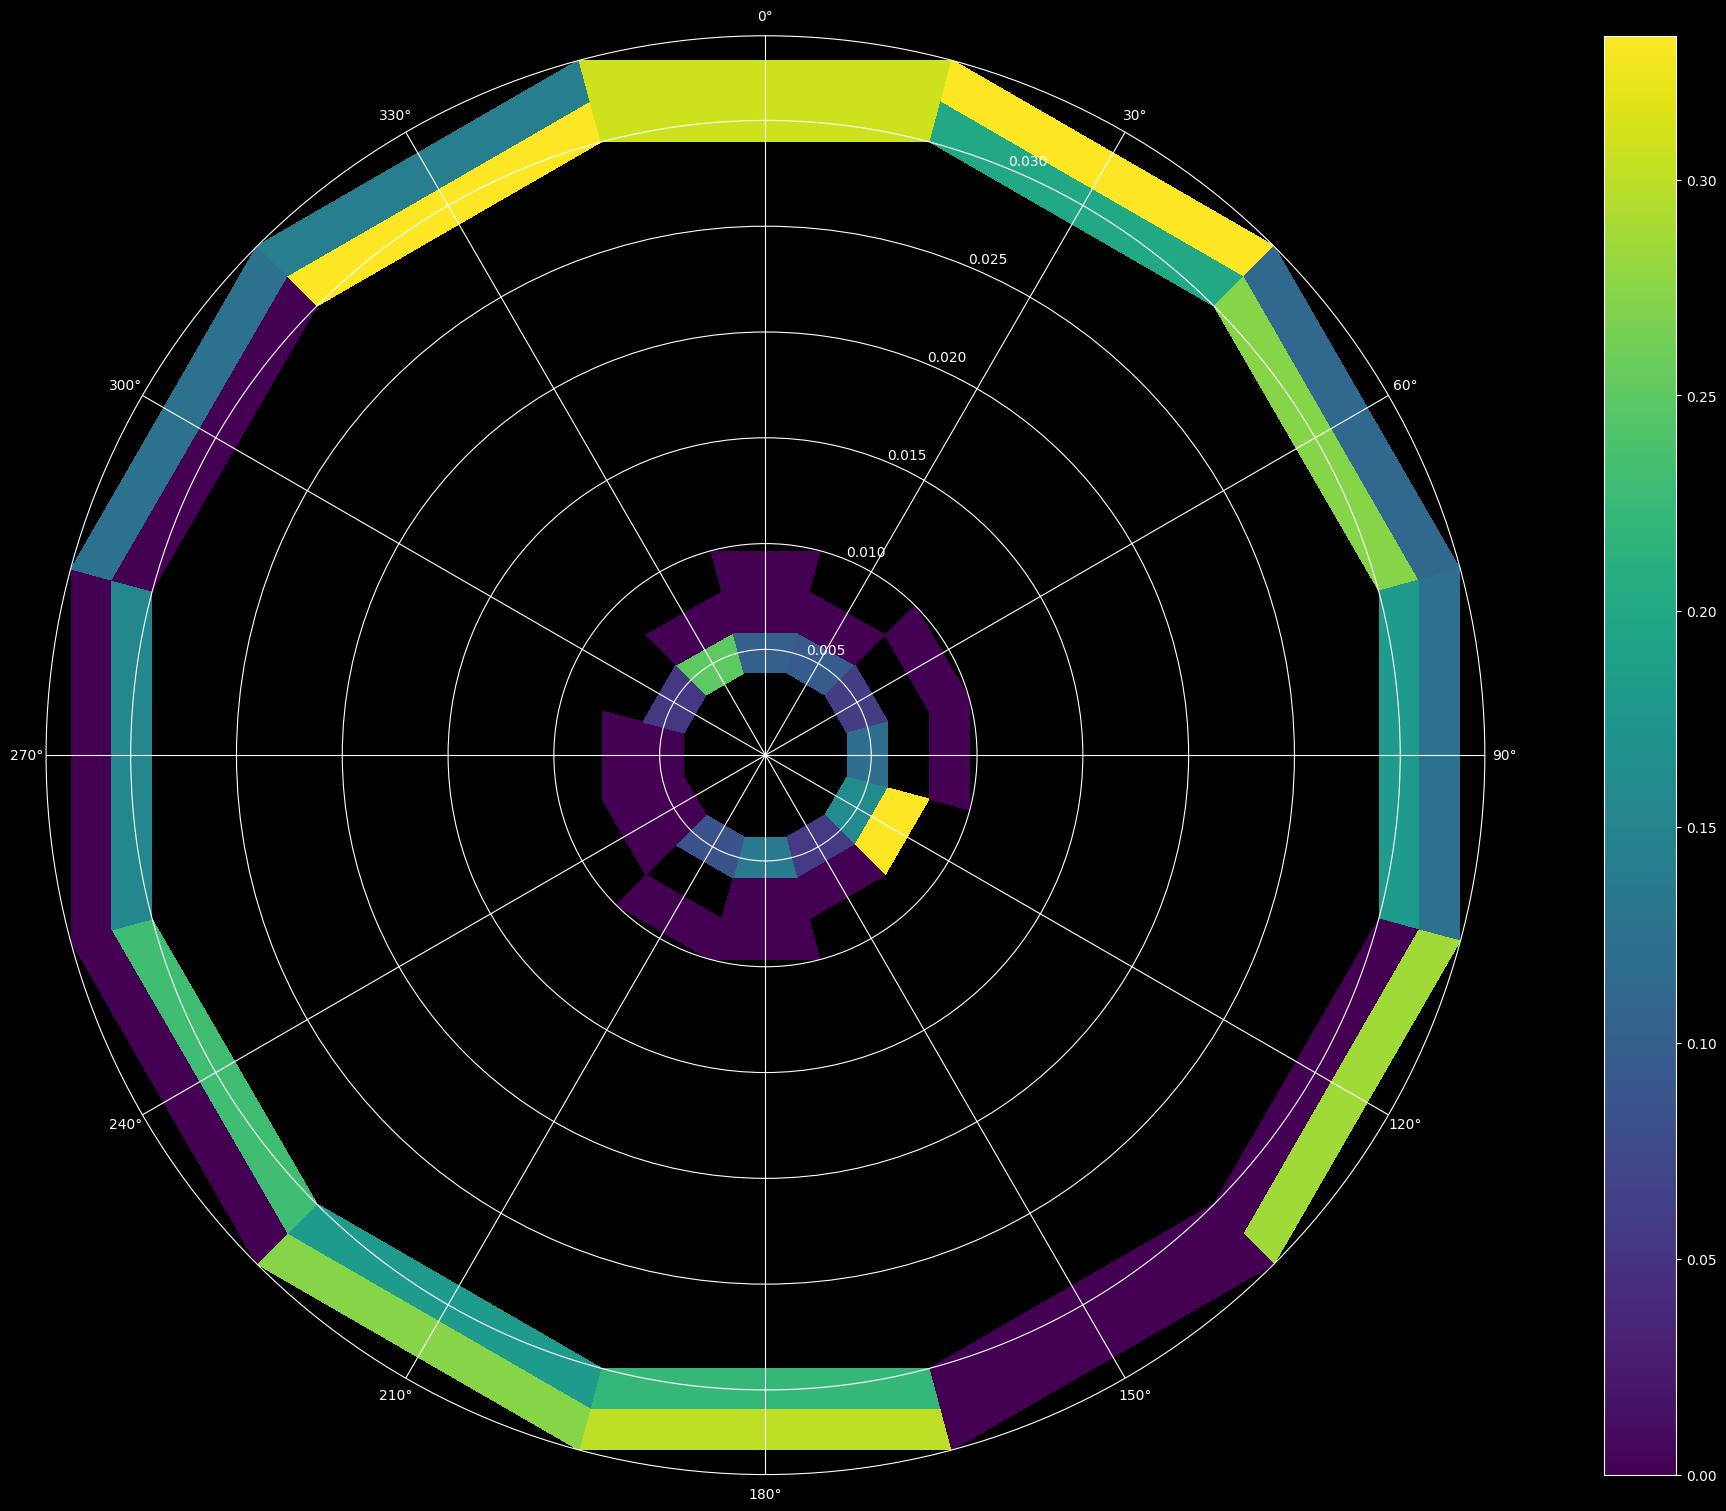

In [104]:
def plot_grid_matrix_into_radial(grid_matrix, spatial_grid_r, spatial_grid_theta, fig_and_ax):
    
    r, theta = np.meshgrid(spatial_grid_r, spatial_grid_theta)
    z = grid_matrix
    # plt.figure(figsize= (10,10))
    fig, axs = fig_and_ax
    im = axs.pcolormesh(theta, r, z, cmap = 'viridis')
    
    axs.set_thetagrids(range(0, 360, int(360/12)))
    axs.set_theta_zero_location("N")
    axs.set_theta_direction(-1)
    return im

fig, ax = plt.subplots(
                1,
                1,
                figsize=(20, 15),
                subplot_kw={"projection": "polar"},
                layout="constrained",
            )
im = plot_grid_matrix_into_radial(prob_grid_11.T, spatial_r, theta, fig_and_ax=(fig,ax))
fig.colorbar(im)

529
529


/tmp/ipykernel_292870/3400566174.py:35: RuntimeWarning: invalid value encountered in divide
  transition_matrix = transition_matrix/row_sums[:, np.newaxis]


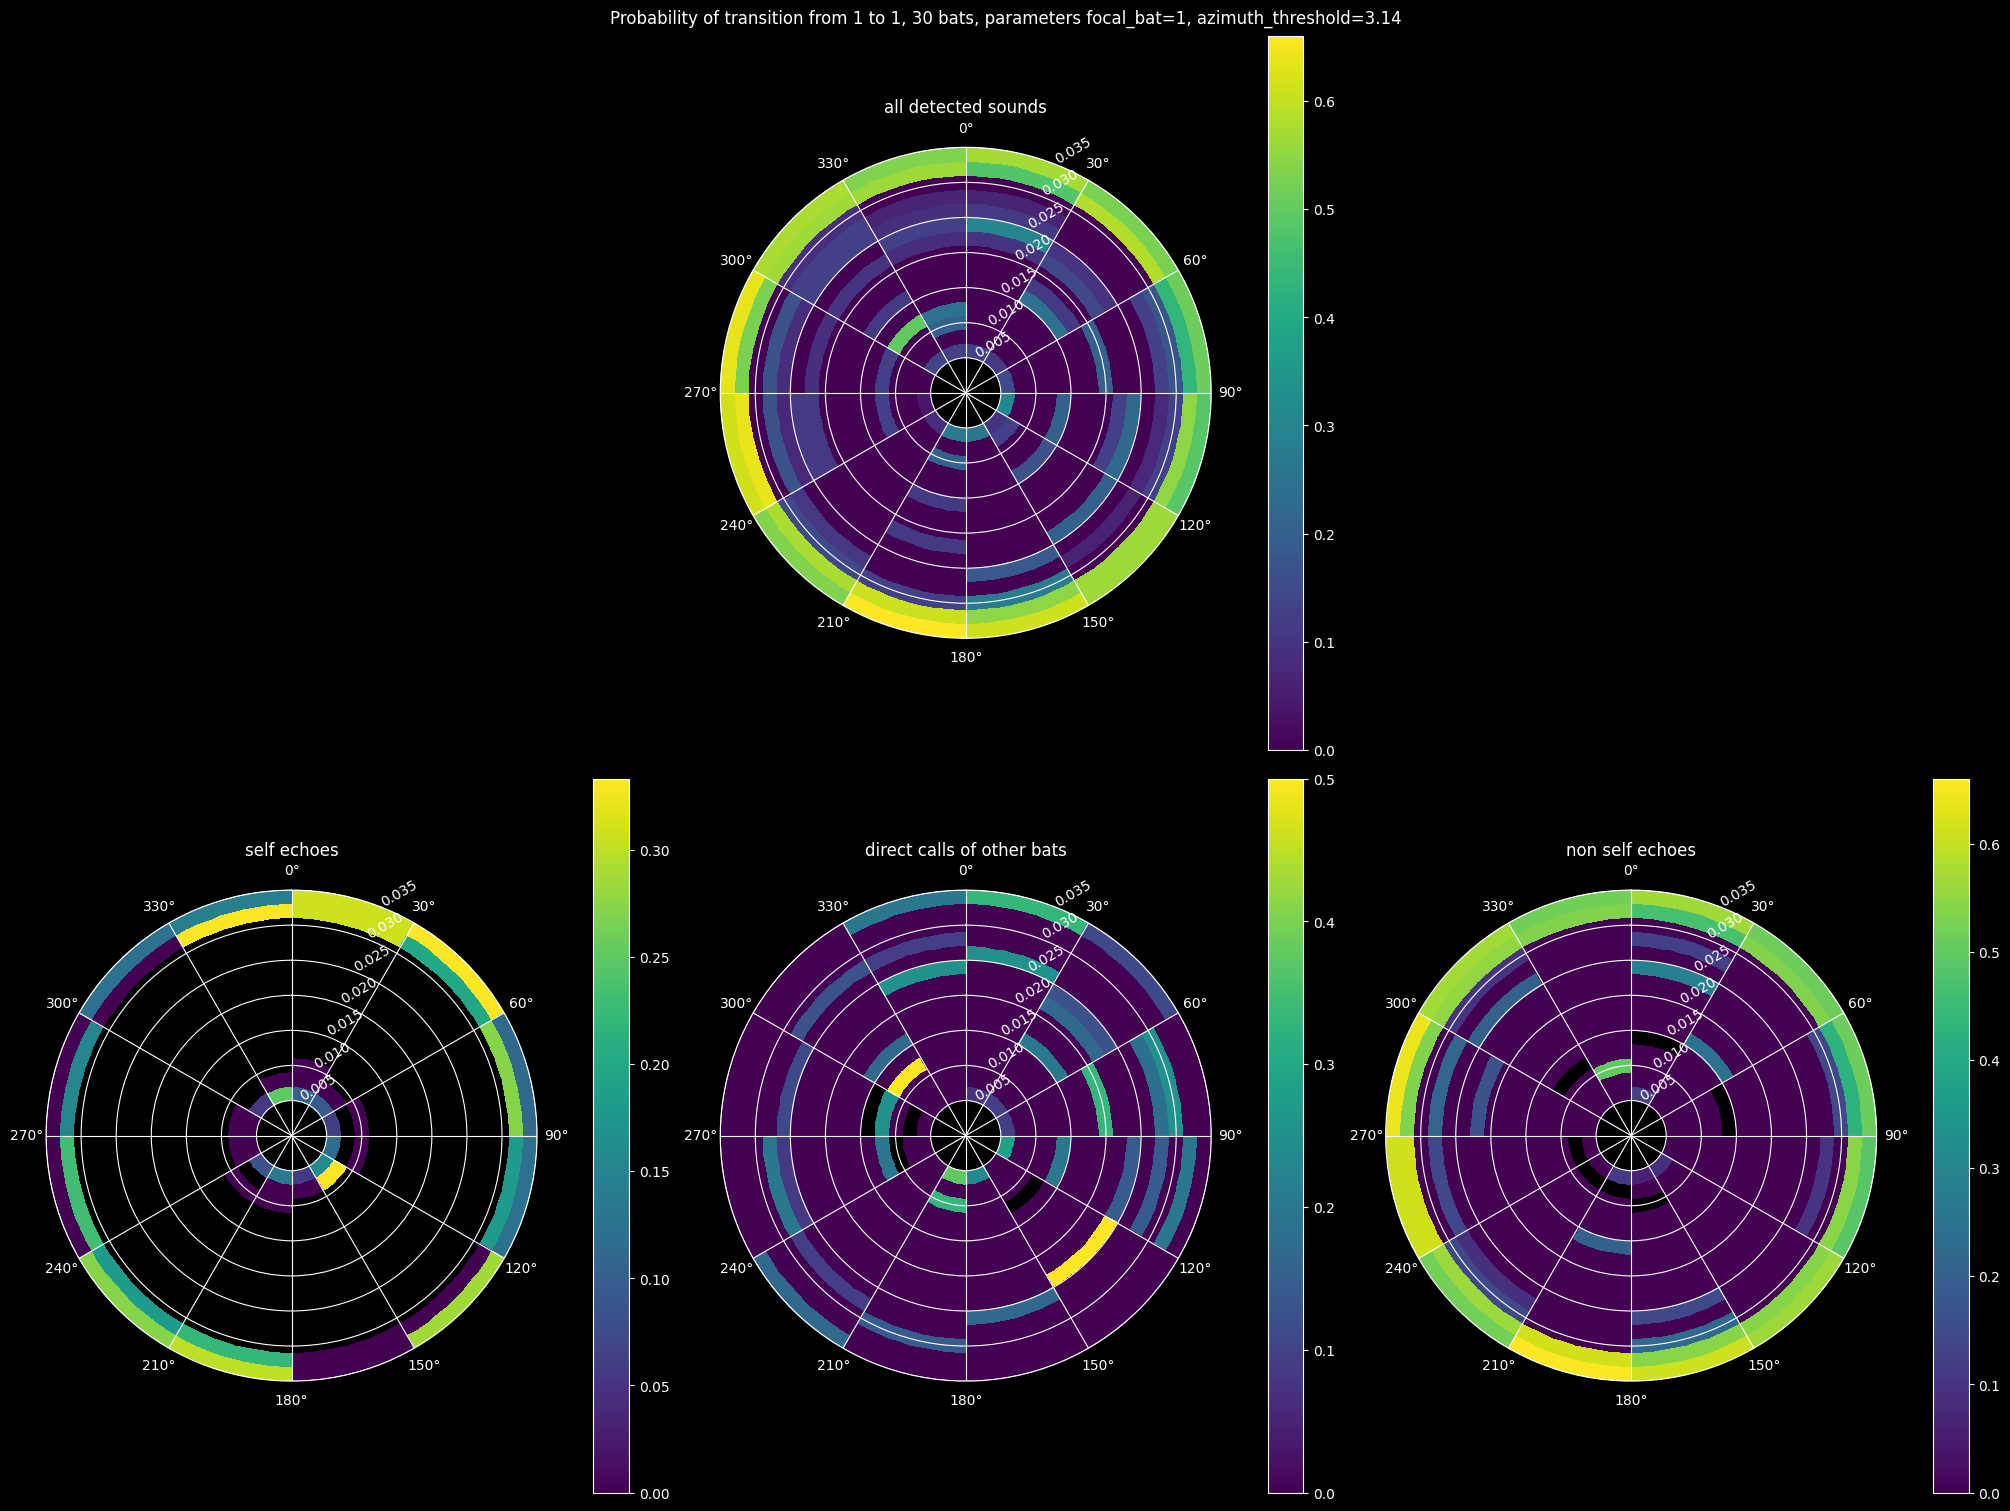

417
417


<Figure size 640x480 with 0 Axes>

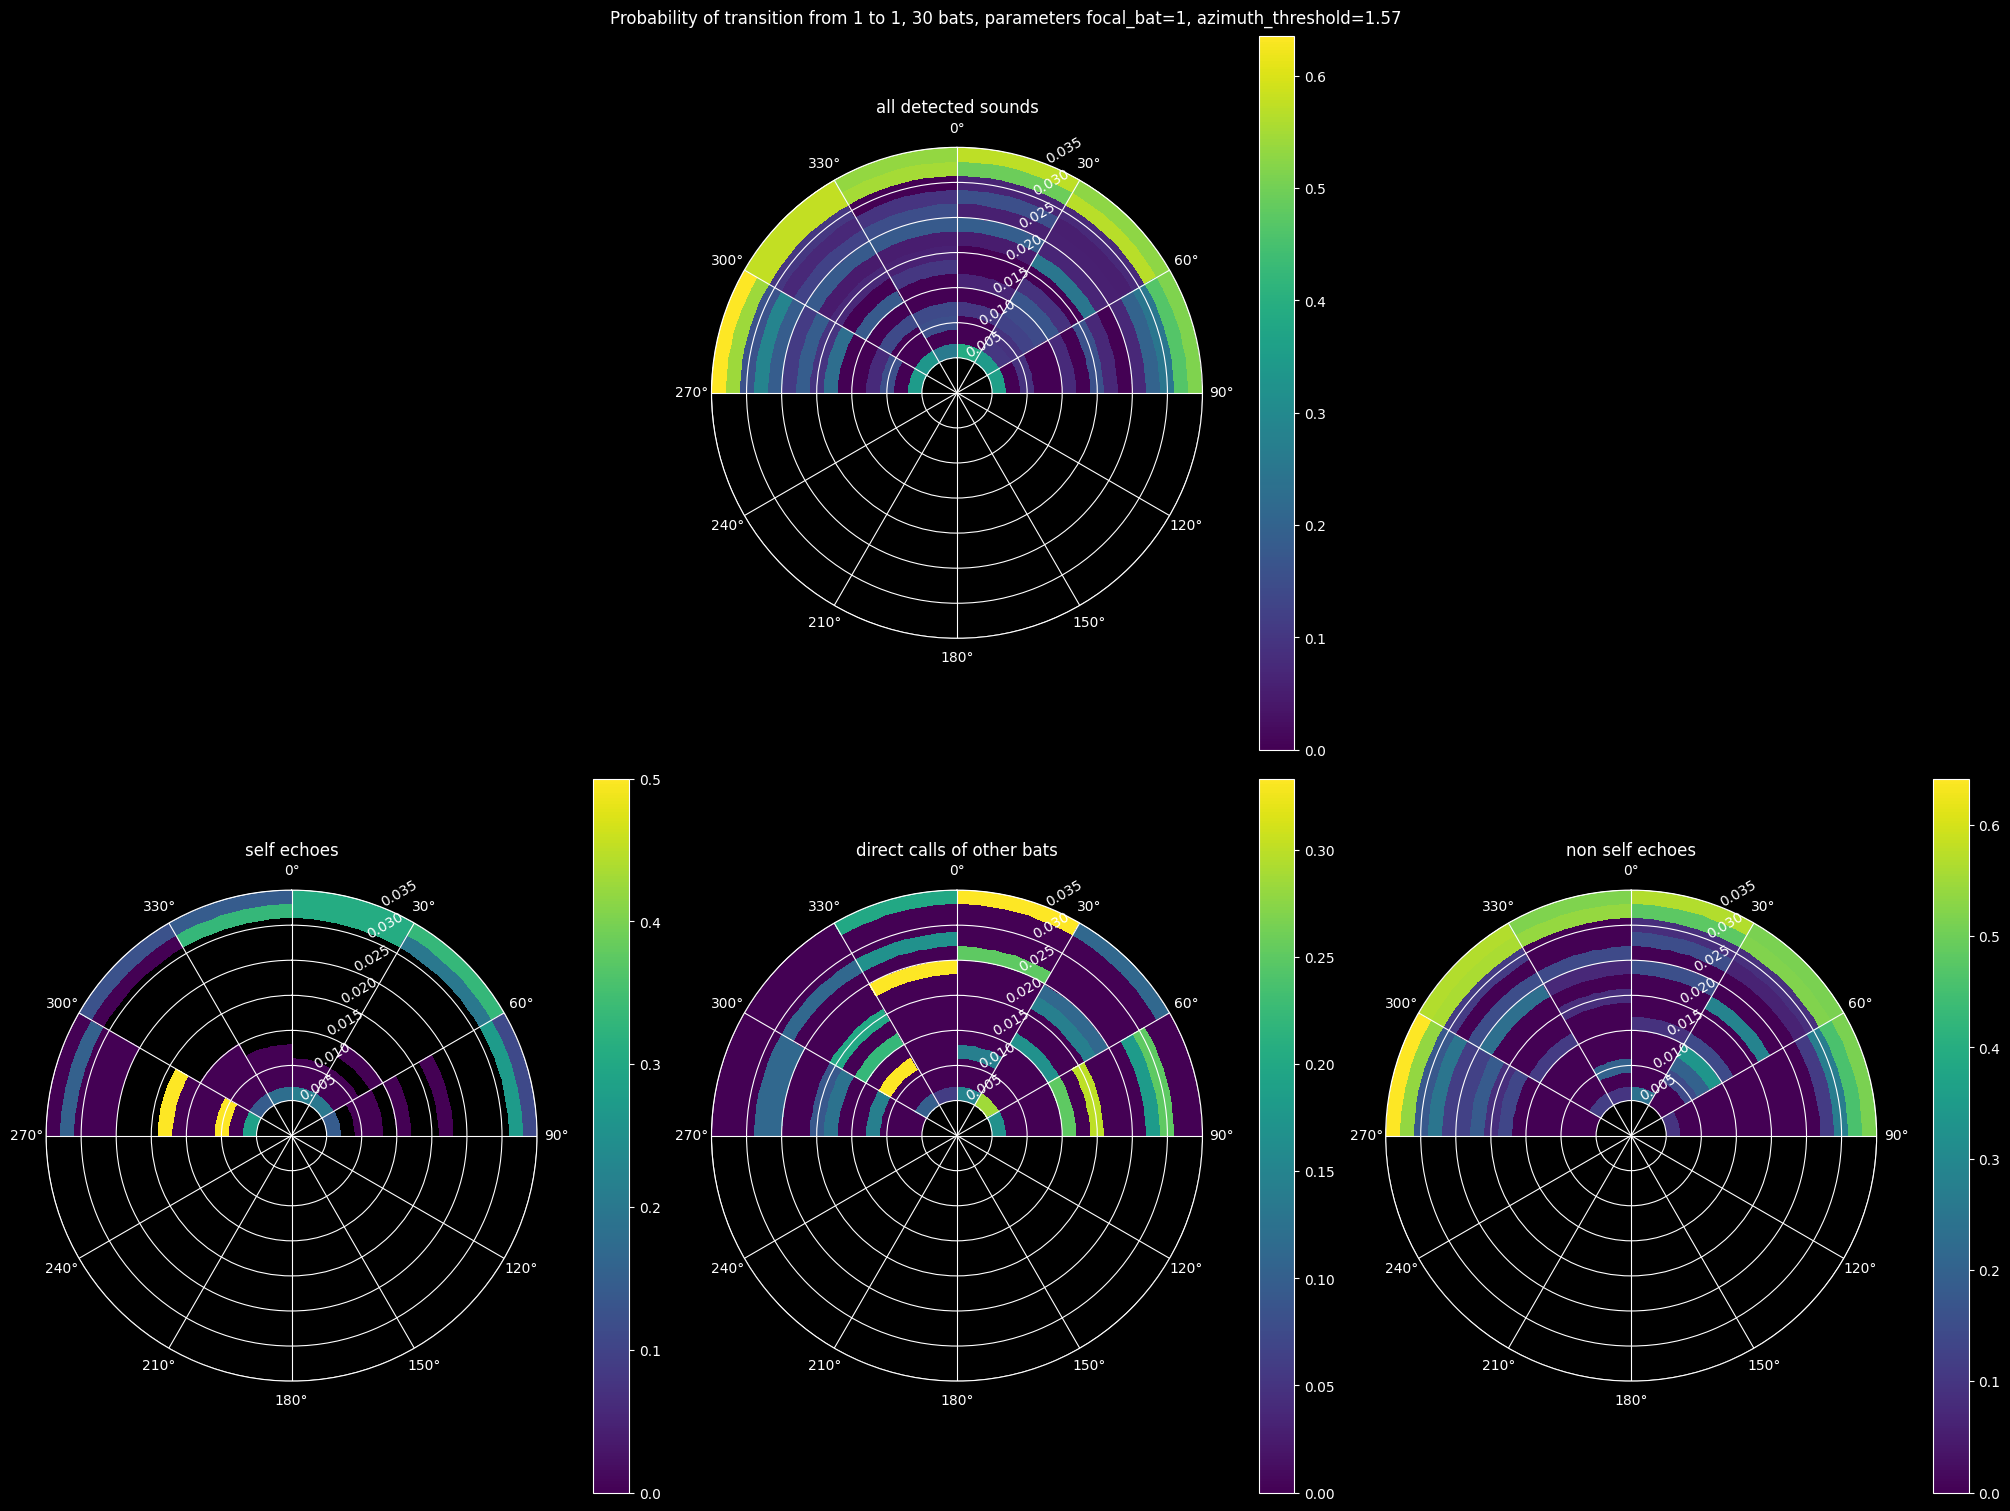

237
237


<Figure size 640x480 with 0 Axes>

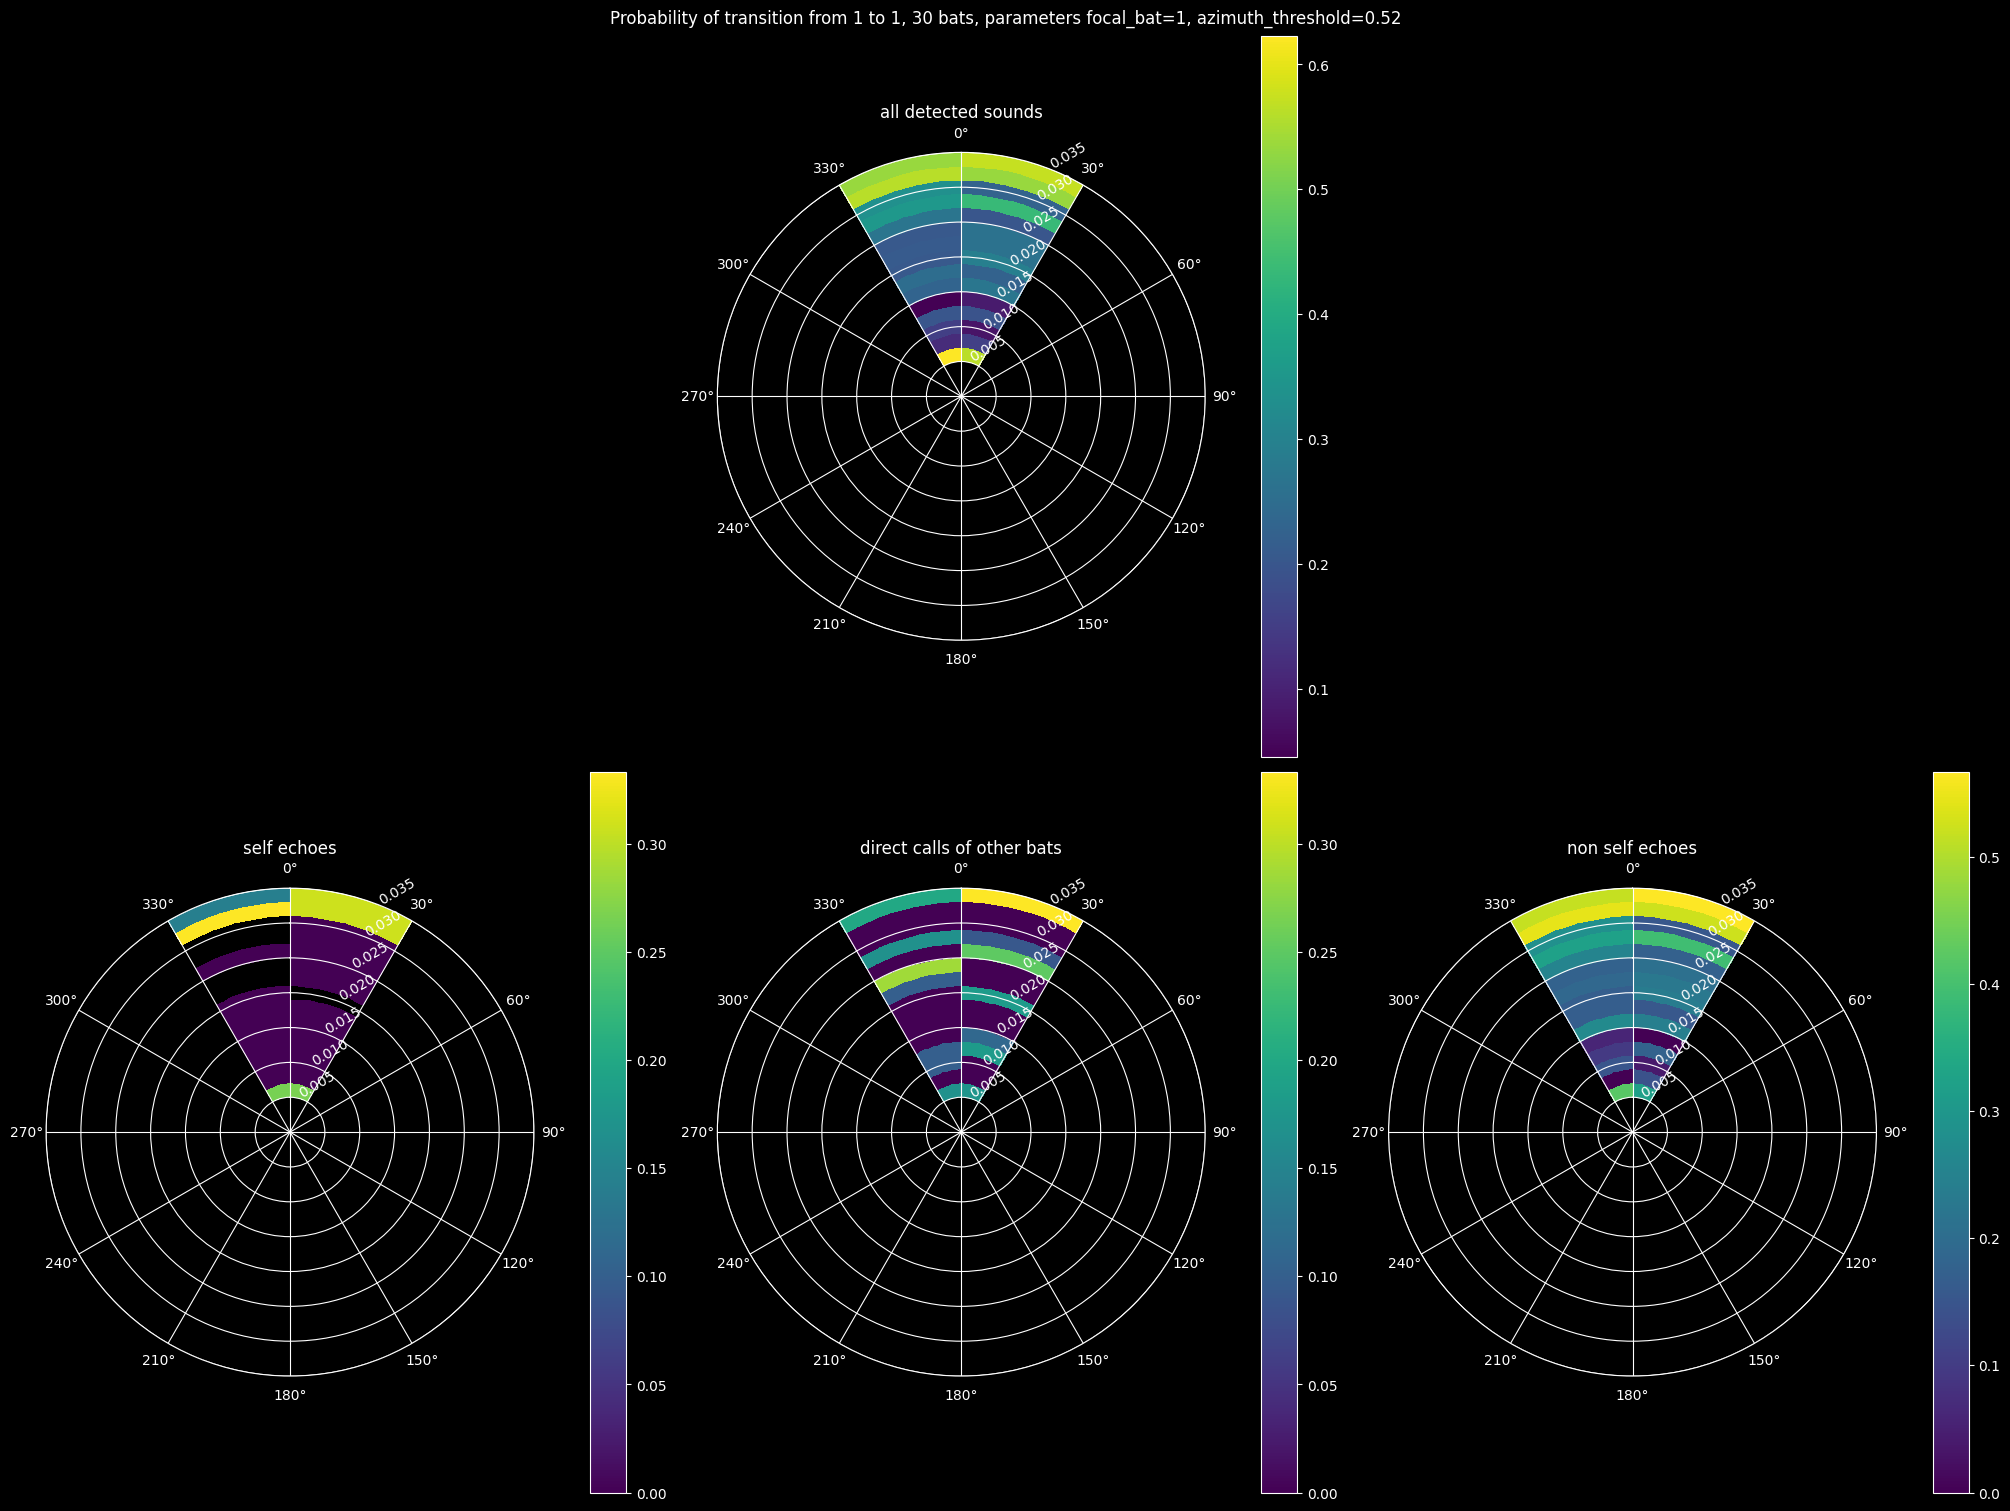

338
338


<Figure size 640x480 with 0 Axes>

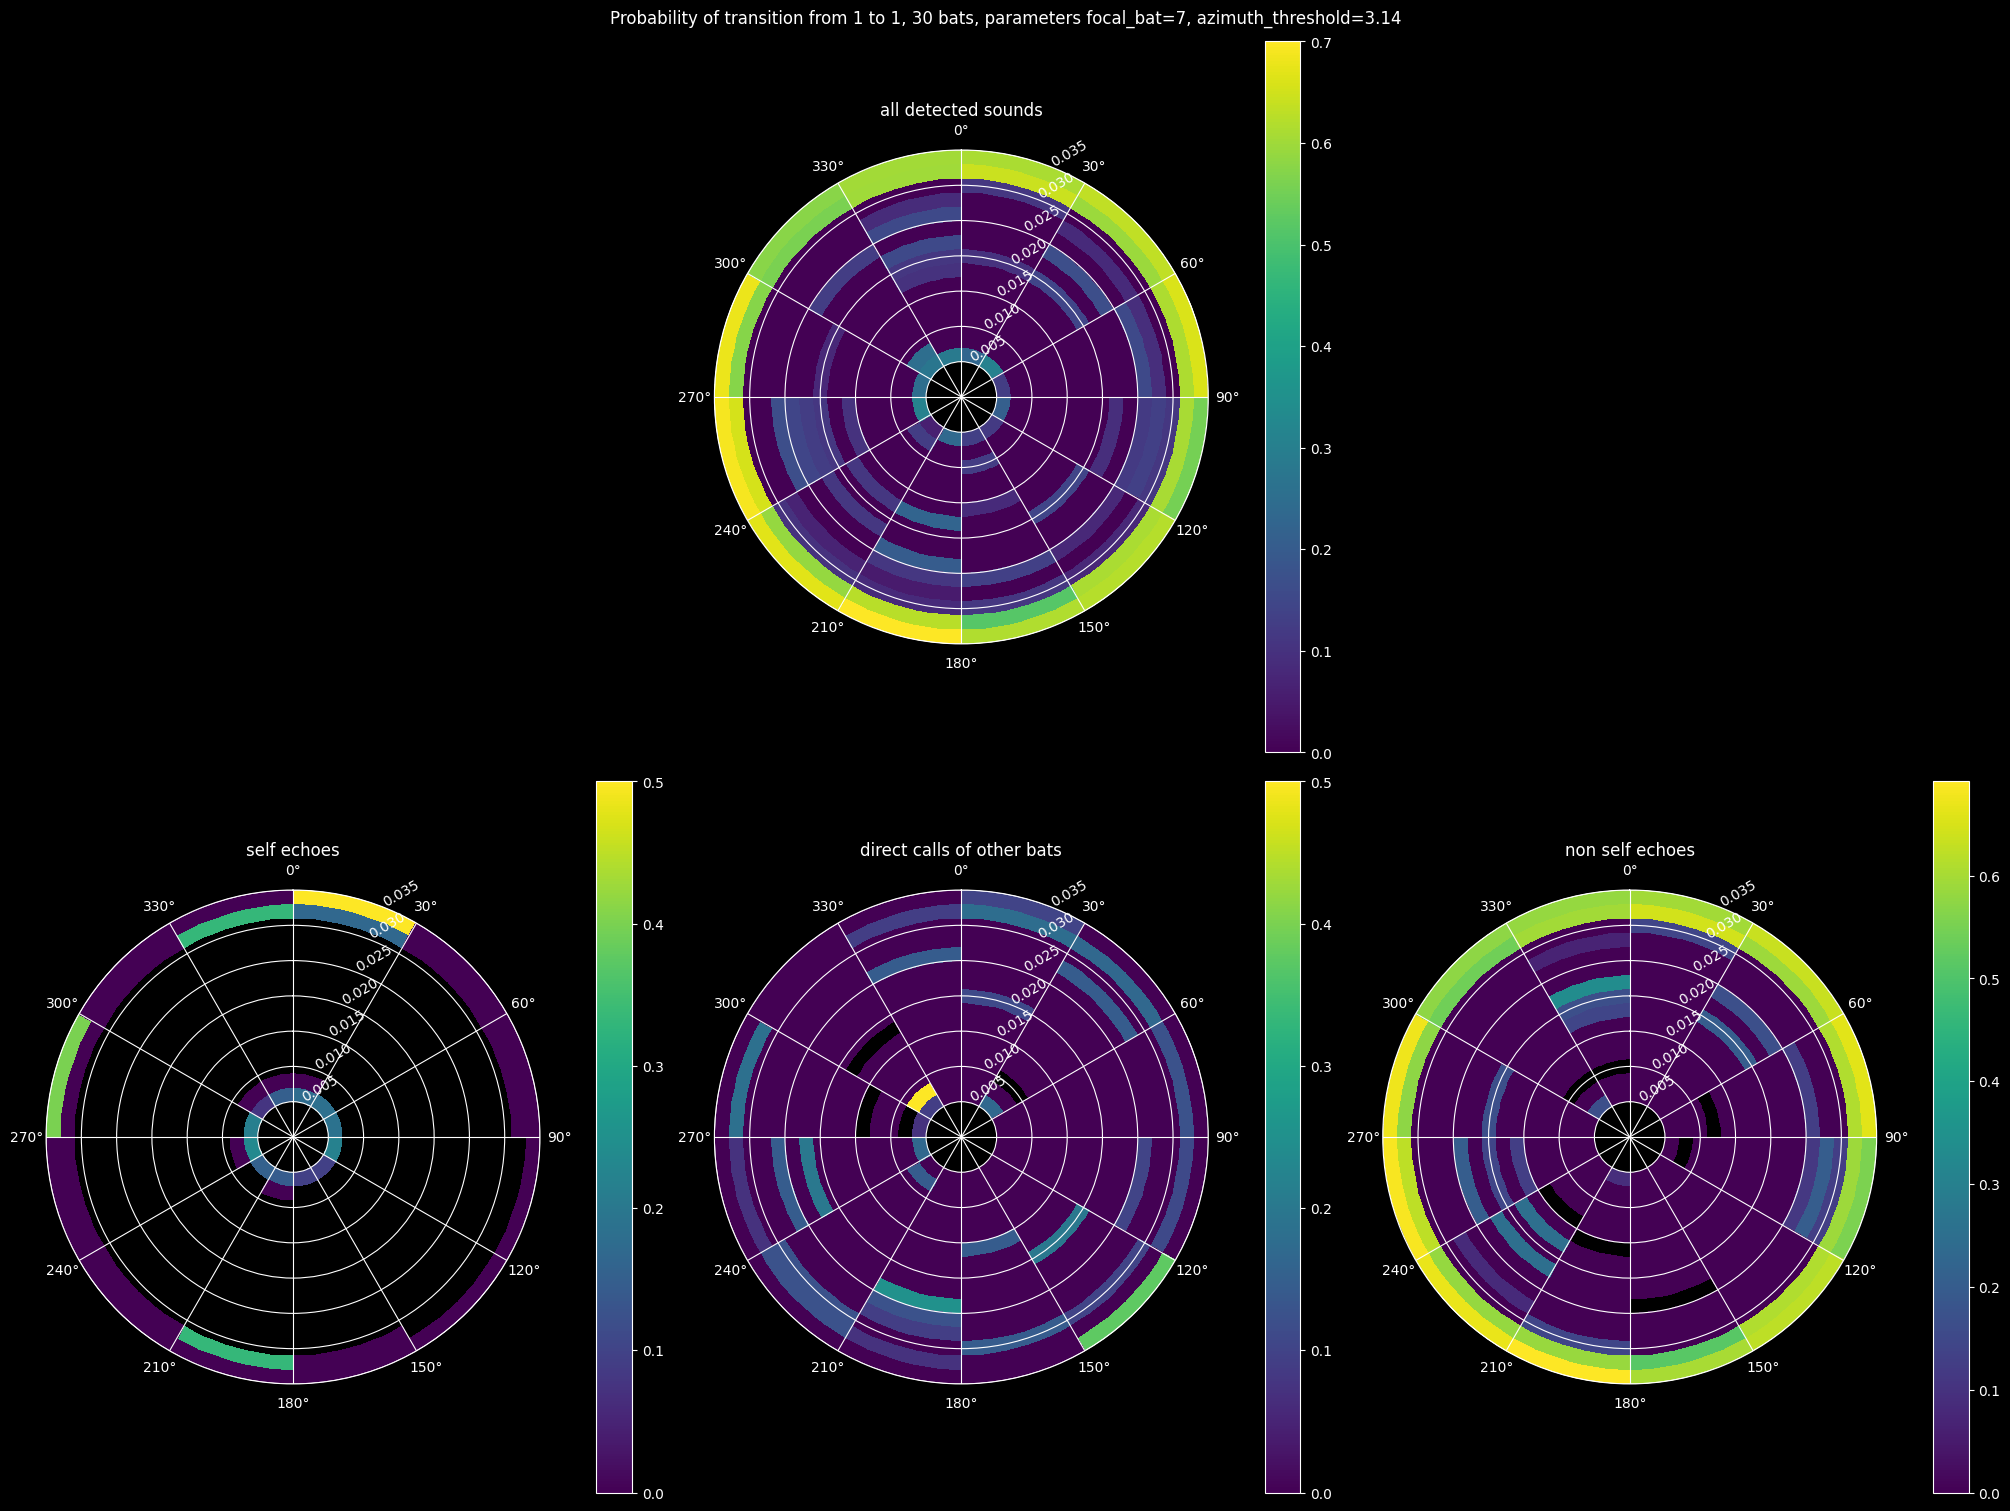

291
291


<Figure size 640x480 with 0 Axes>

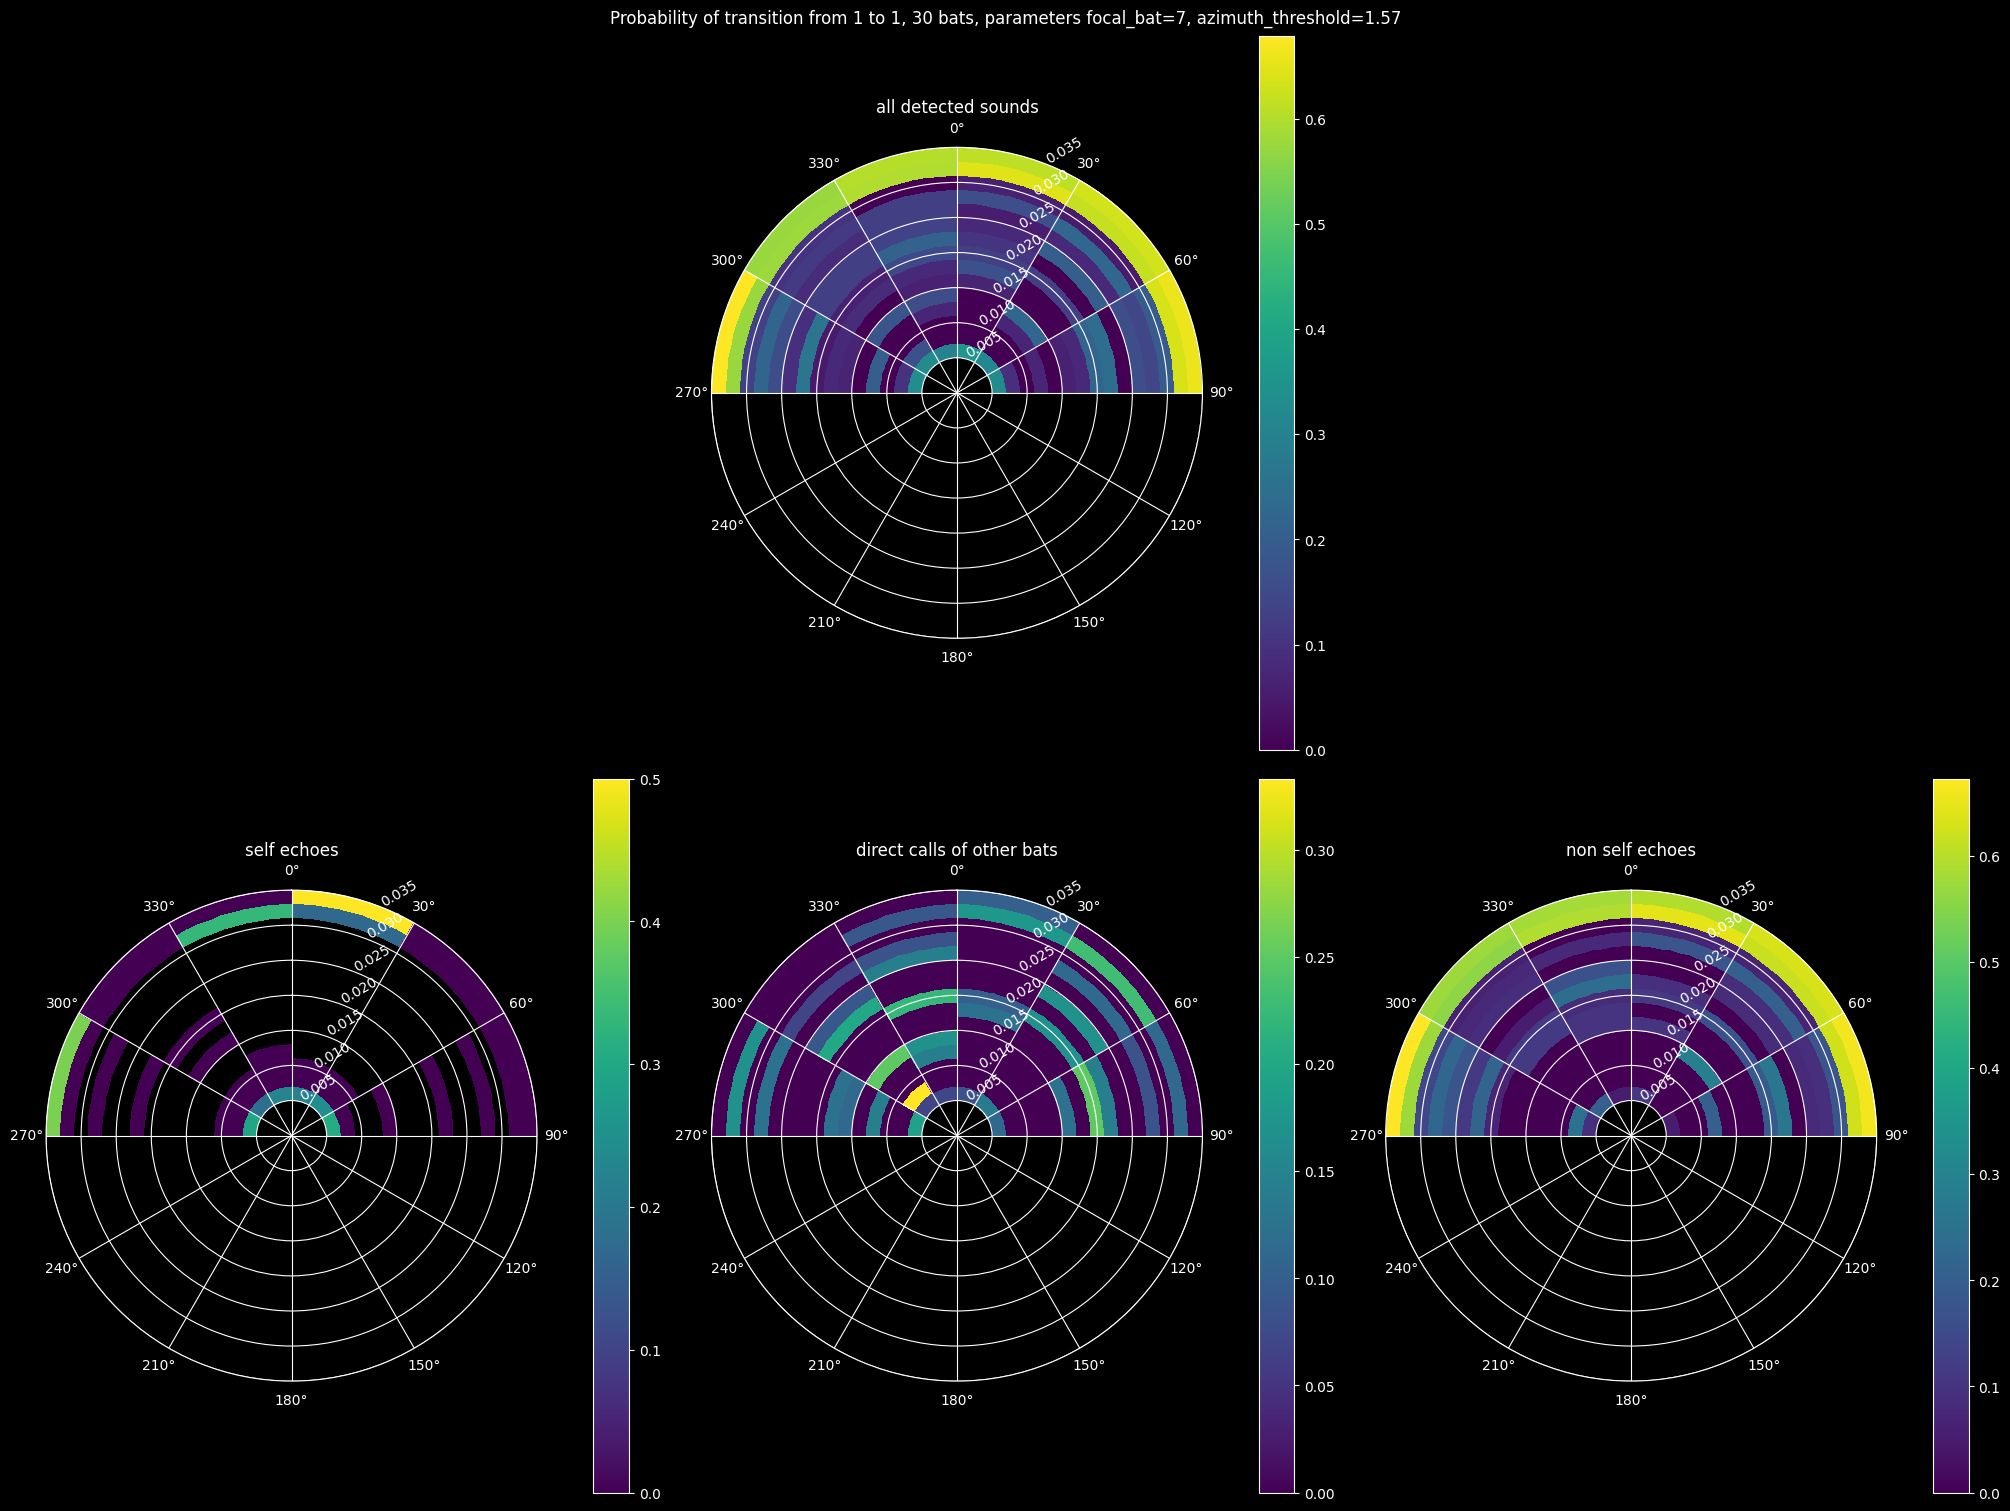

230
230


<Figure size 640x480 with 0 Axes>

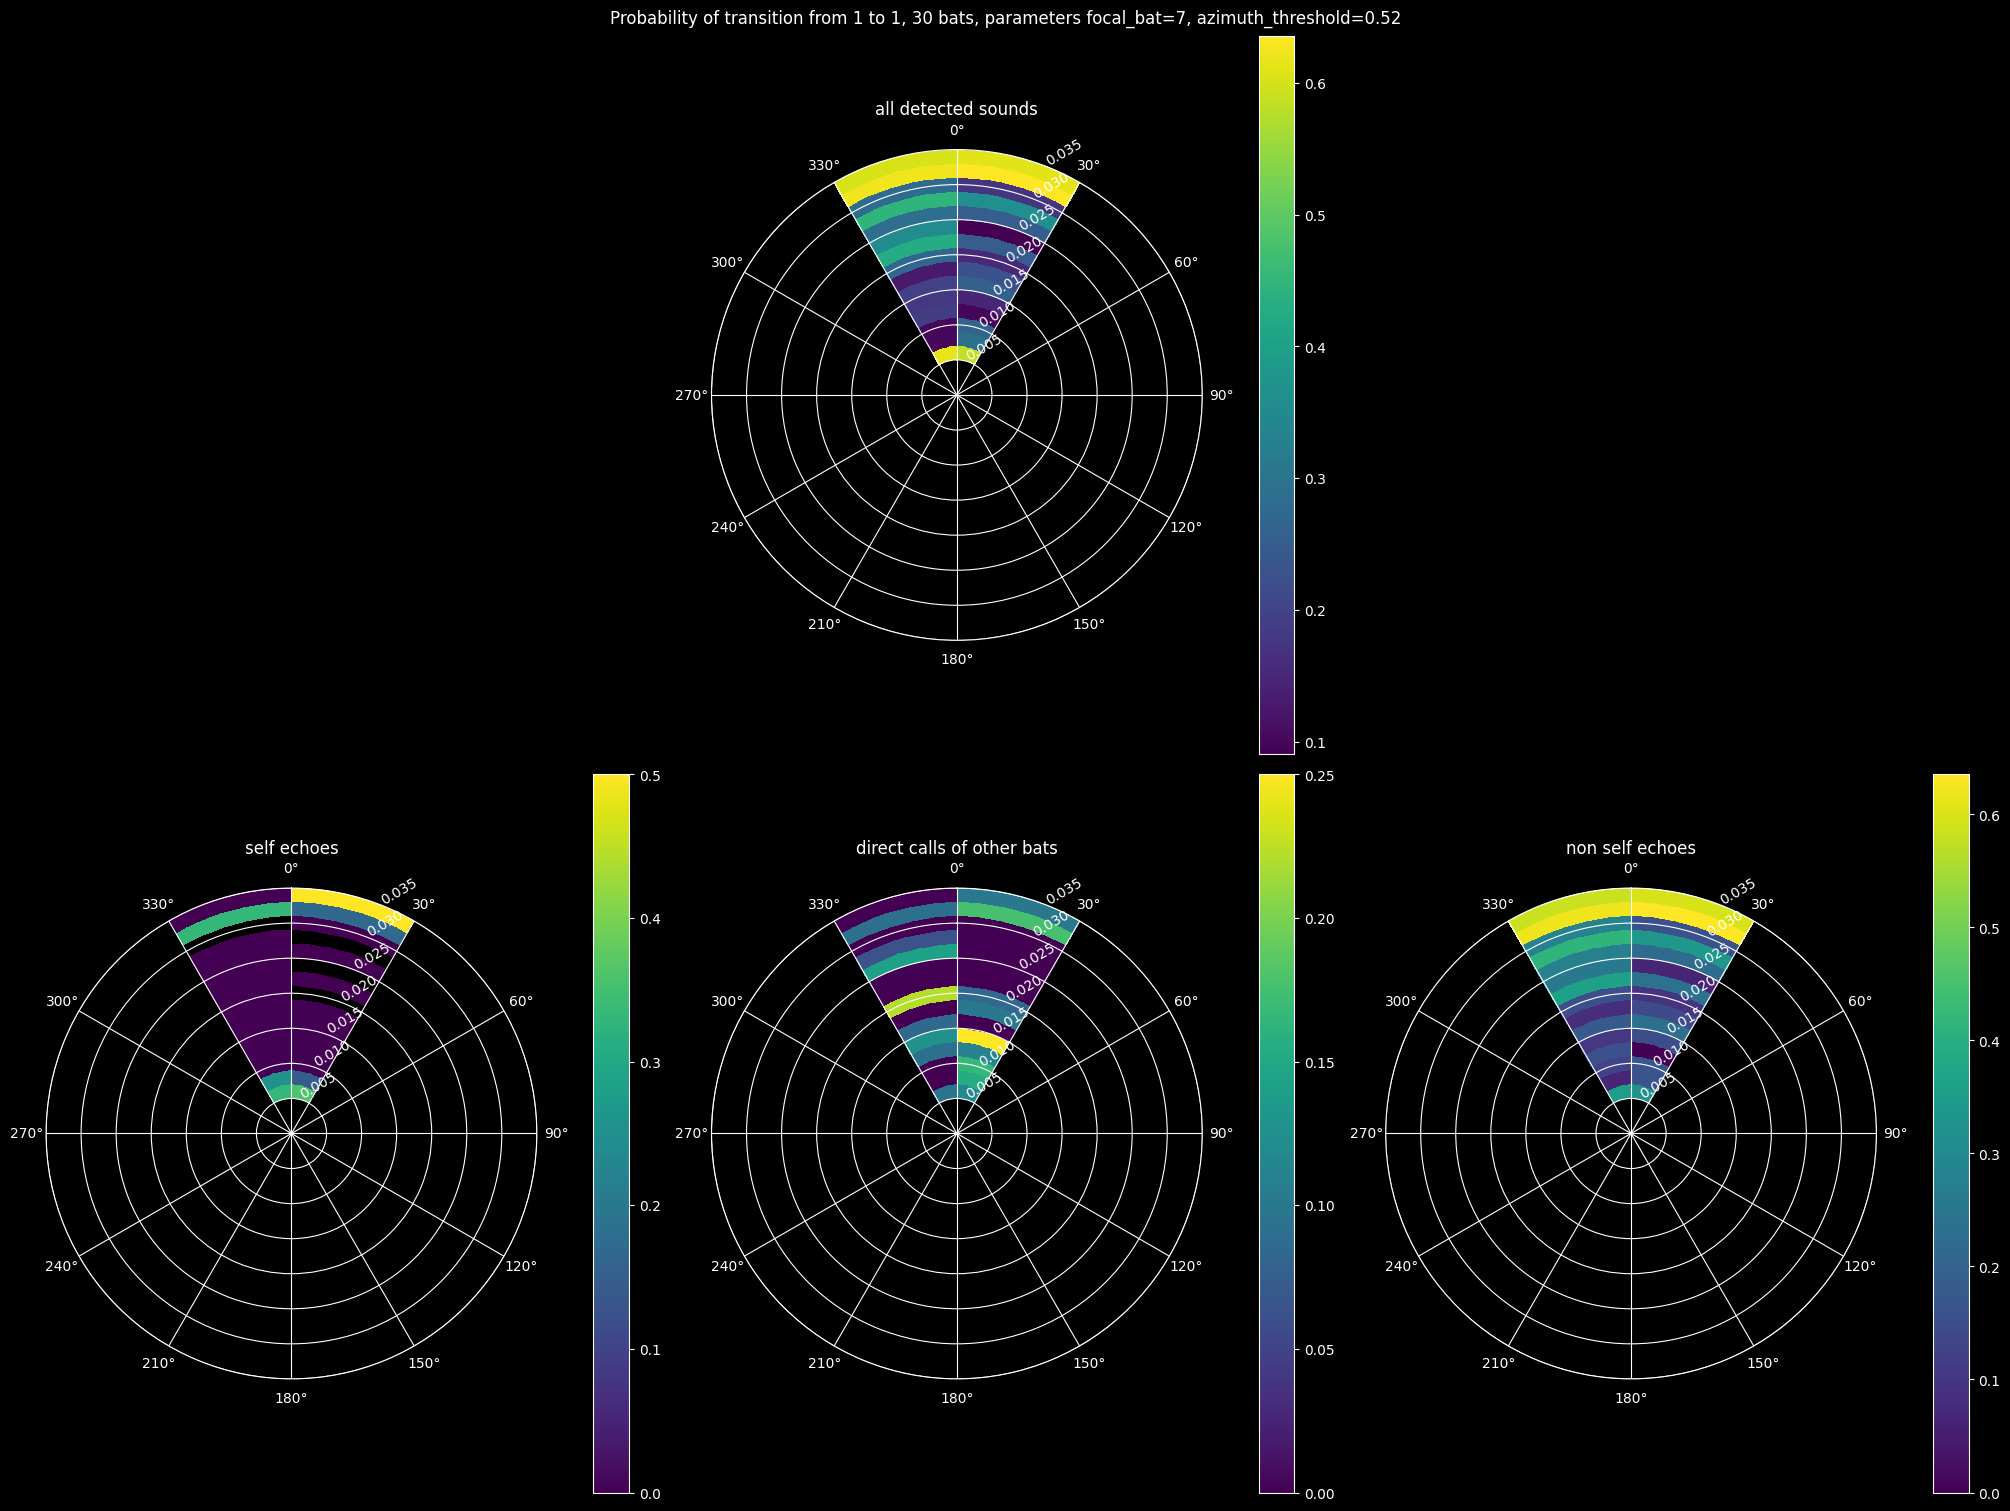

616
616


<Figure size 640x480 with 0 Axes>

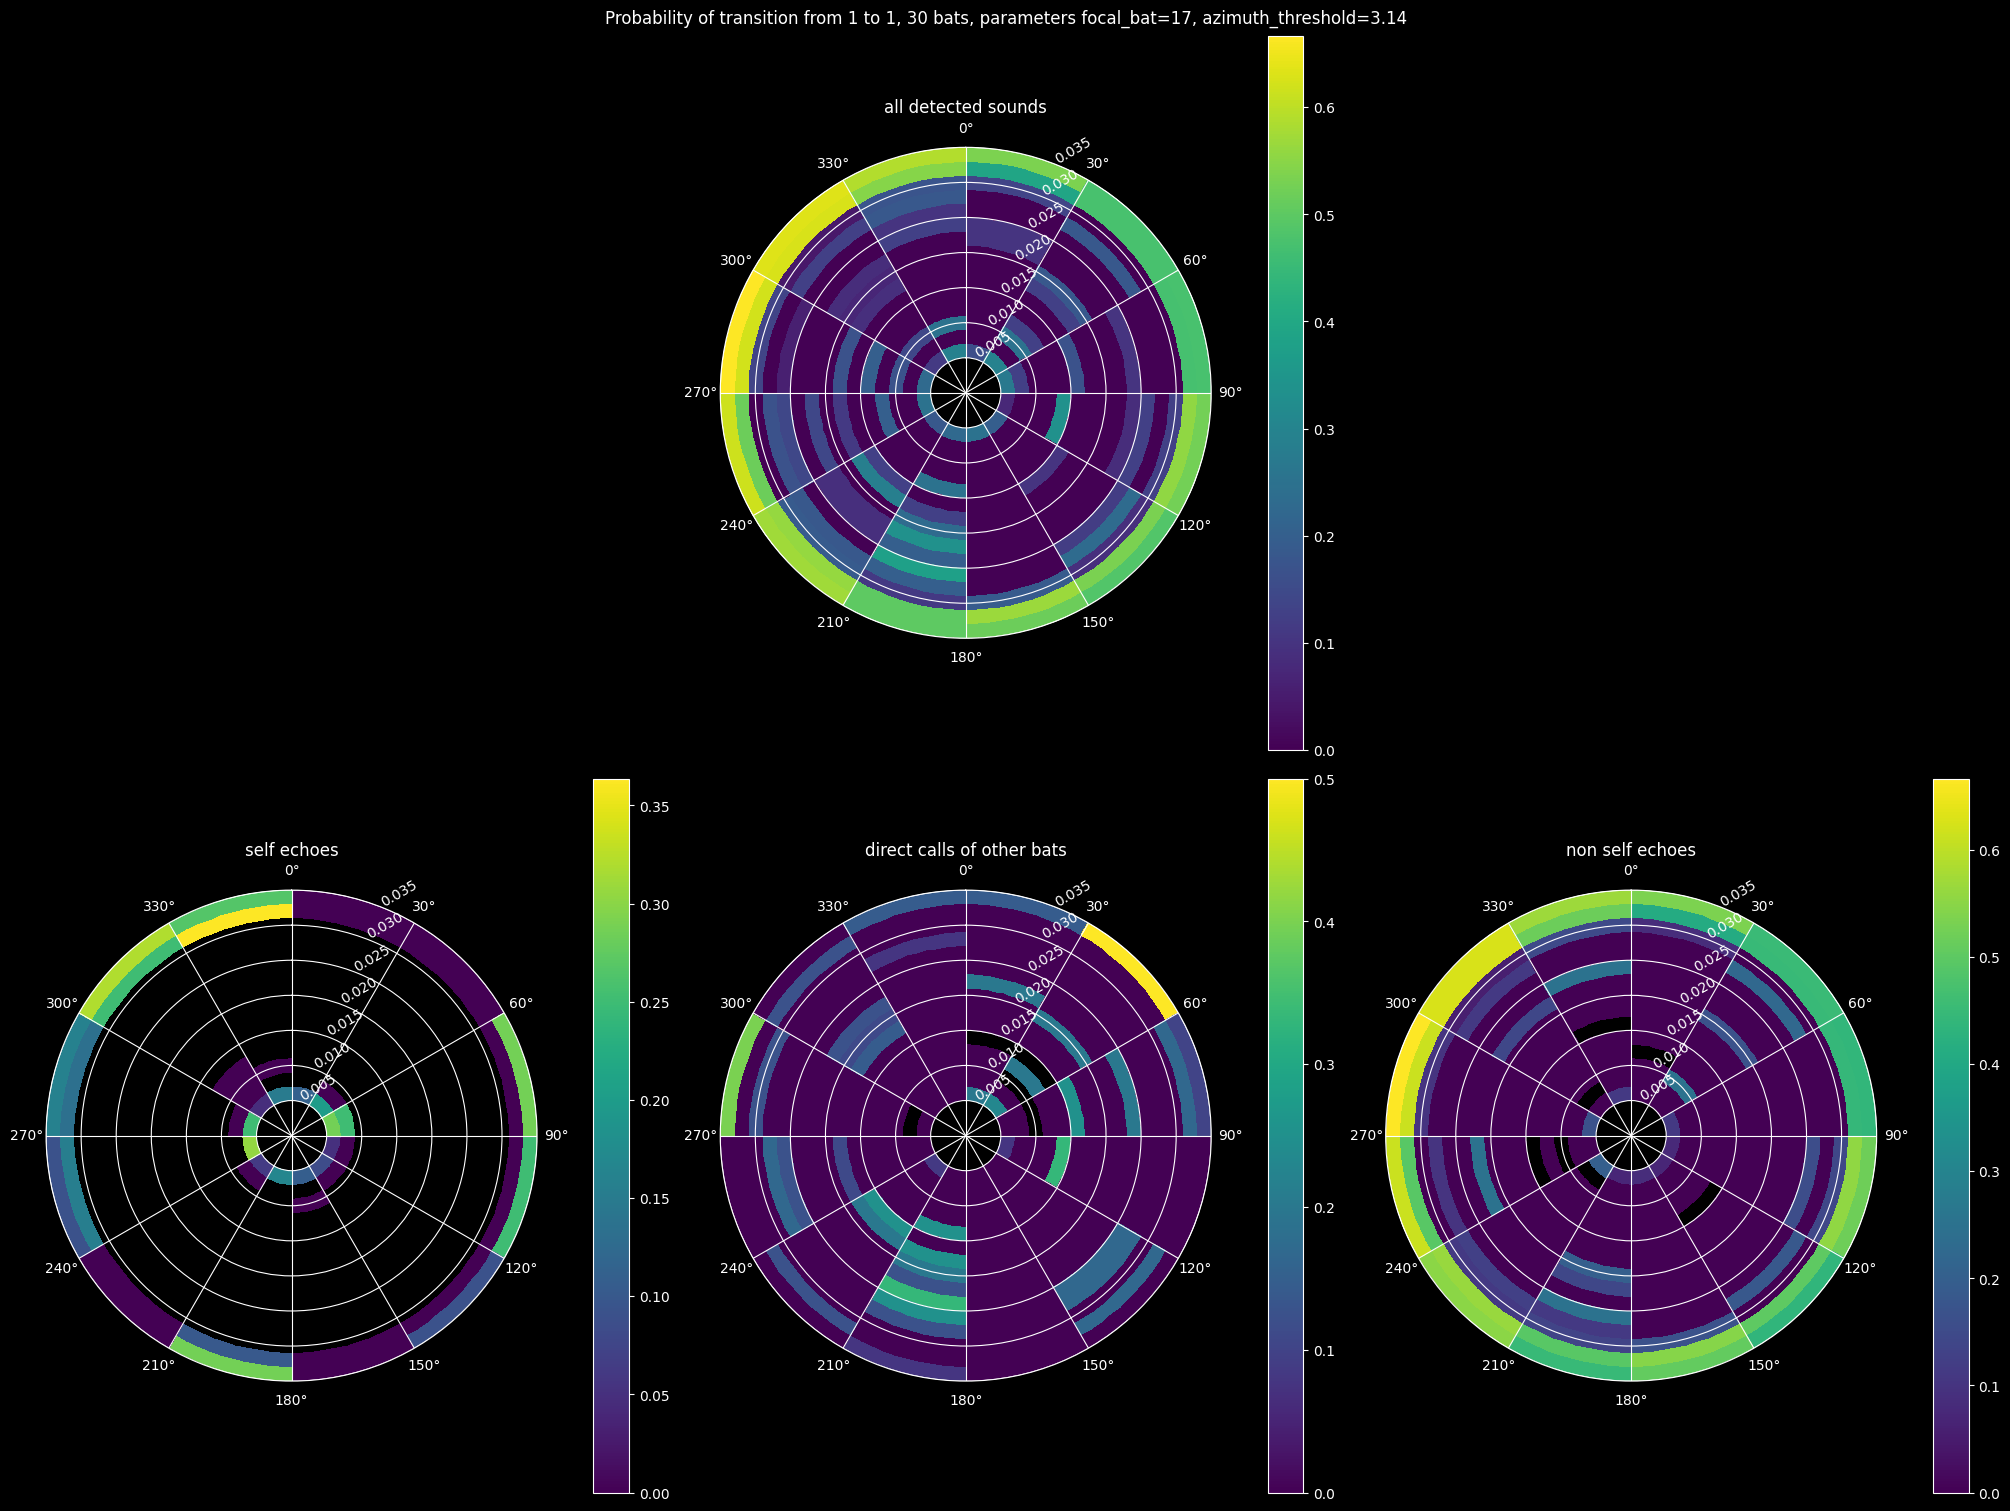

472
472


<Figure size 640x480 with 0 Axes>

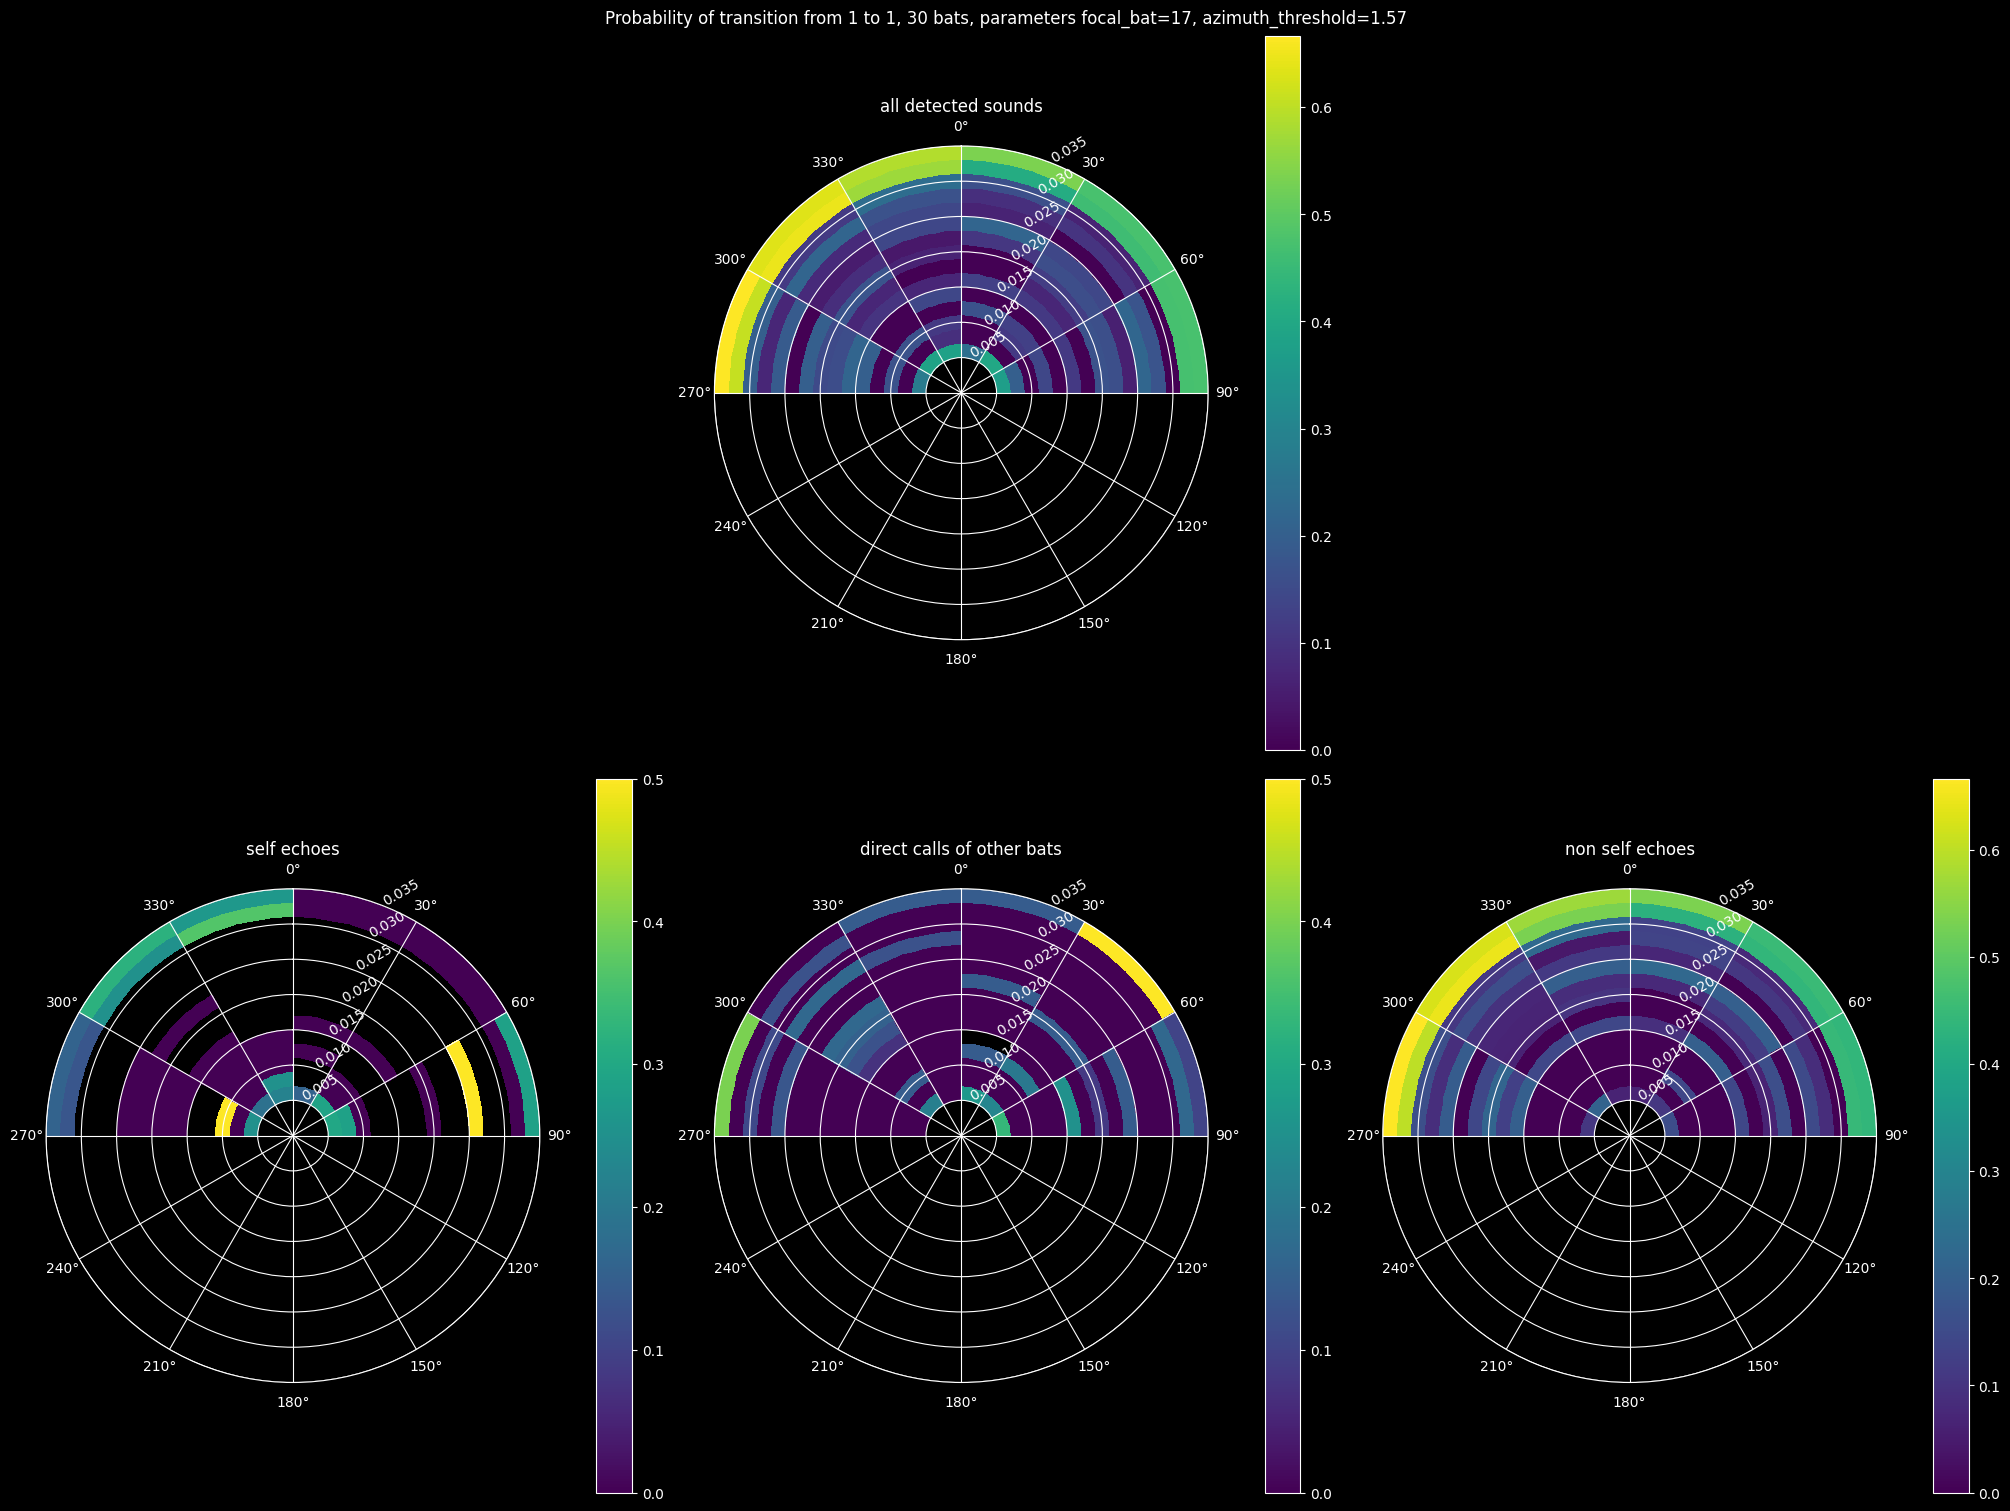

239
239


<Figure size 640x480 with 0 Axes>

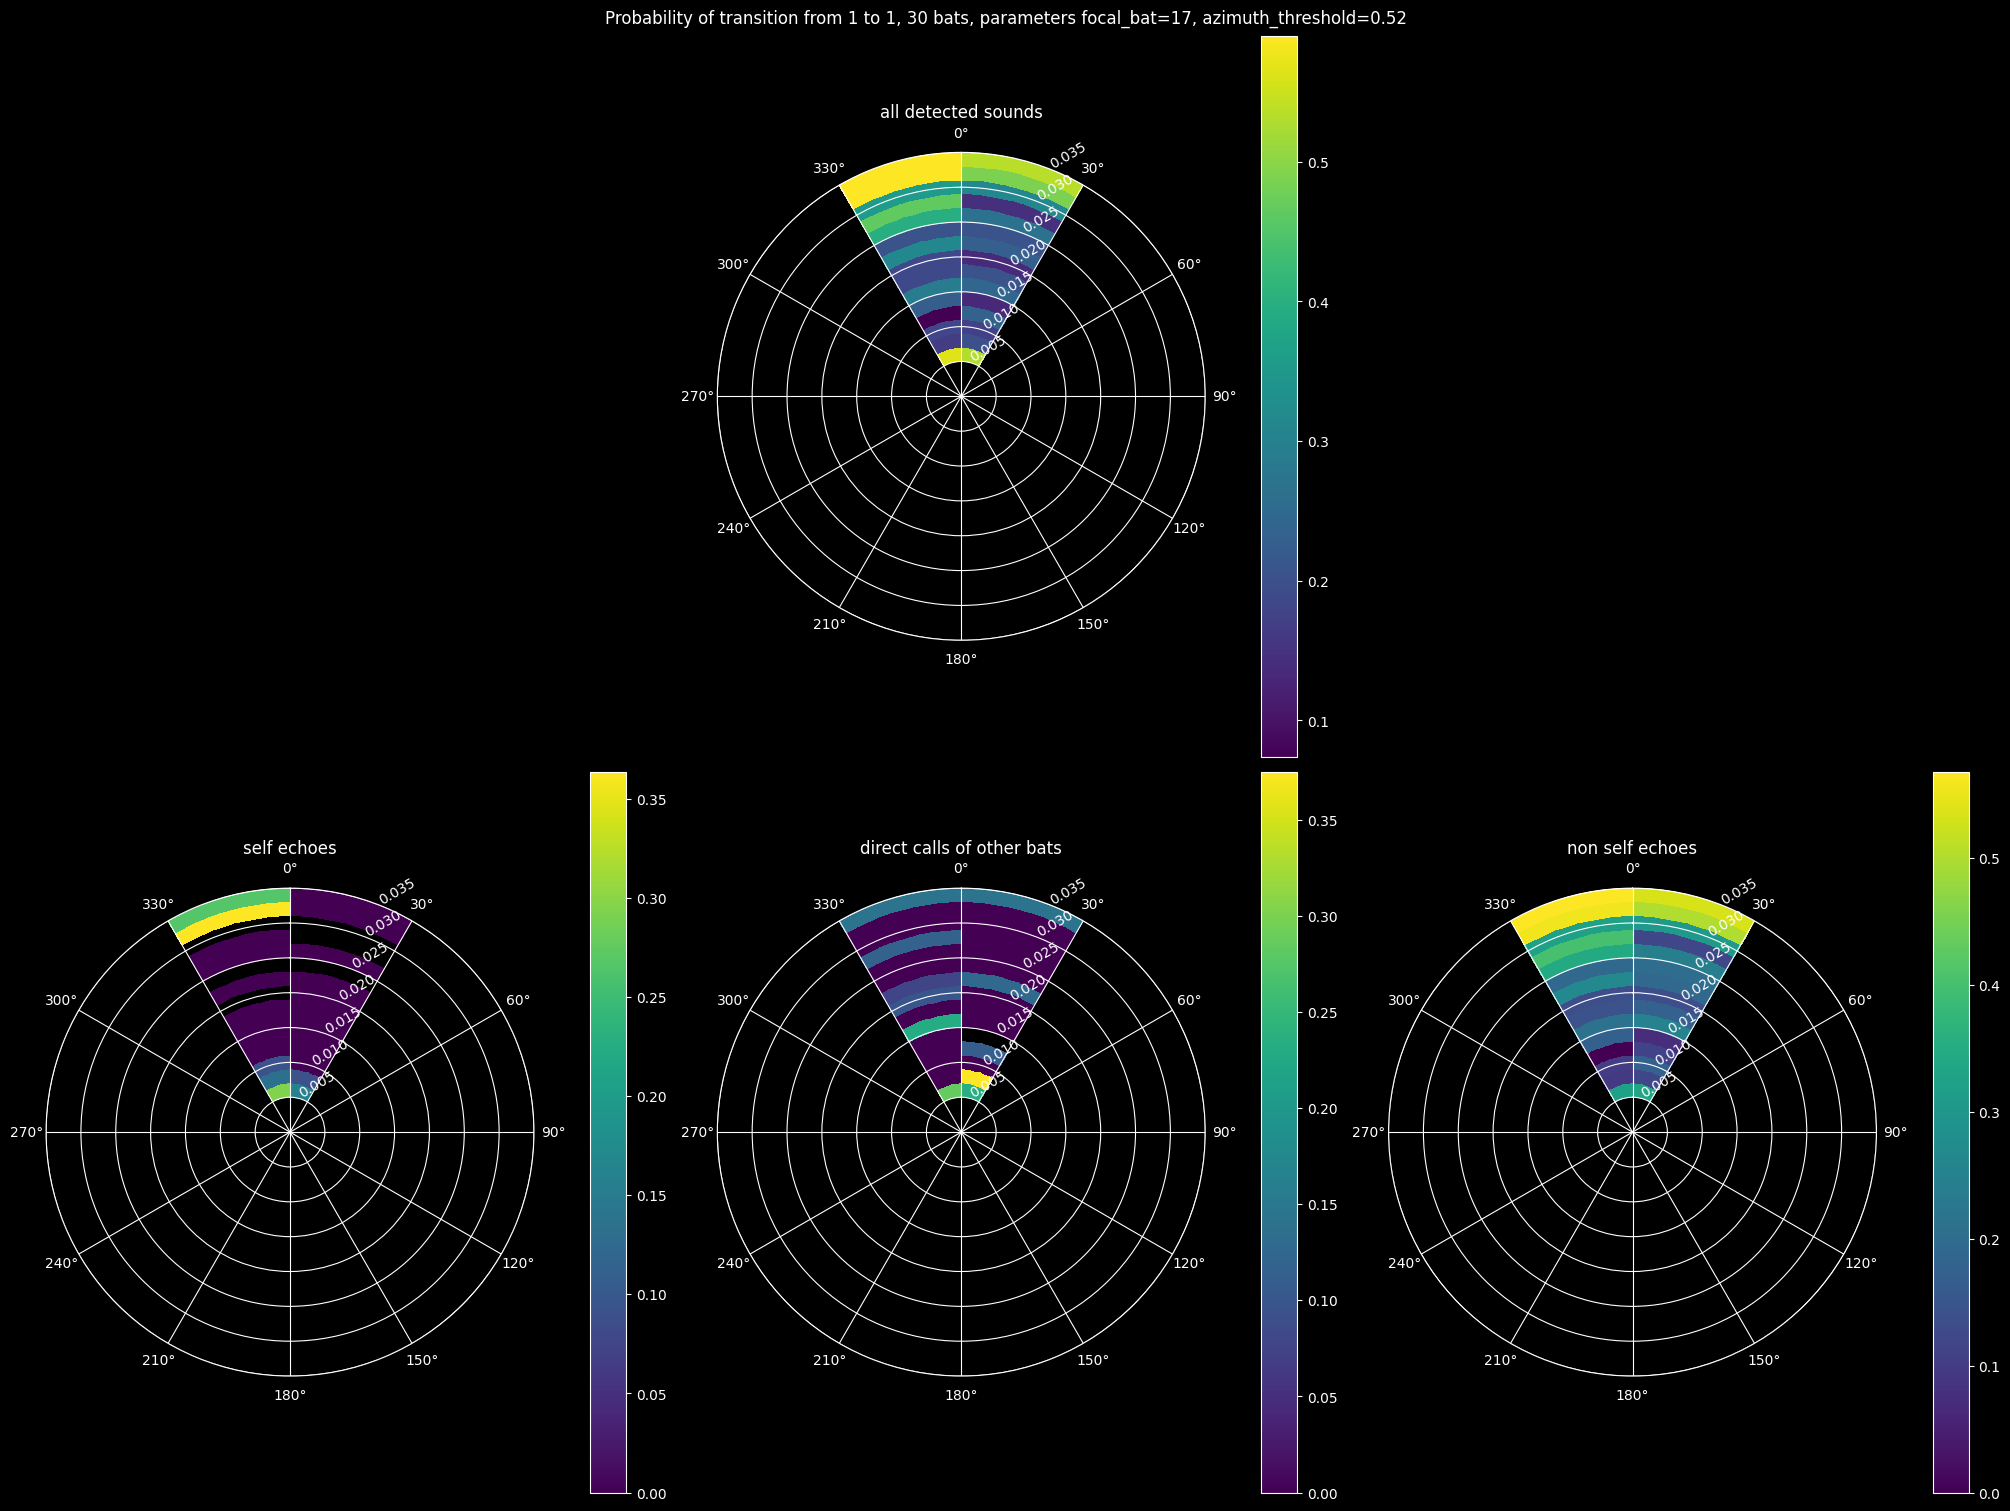

<Figure size 640x480 with 0 Axes>

In [119]:
for param in ordered_list_of_parameters:
    
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    heard_sounds_array = dictionary_to_store_heard_sounds[param]
    grid_data, rows, columns = convert_into_grids(heard_sounds_array, param)
    grid_data_time_series, rows, columns = convert_into_grids_time_series(heard_sounds_array, param)
    
    spatial_grid_r = np.arange(0.005+RADIAL_RESOLUTION/2,0.035,RADIAL_RESOLUTION)
    spatial_grid_theta = np.arange(-np.pi+ANGULAR_RESOLUTION/2, np.pi, ANGULAR_RESOLUTION)
    
    grid_data_probabilities = get_probabilities_for_grid_one_hot(grid_data_time_series, (1,1))
    
    # print(grid_data_probabilities)
    new_grid_data, new_angular_resolution = convert_matrix_for_plotting_nicer(grid_data_probabilities, spatial_grid_r, spatial_grid_theta, 10)
    new_spatial_grid_theta = np.arange(-np.pi+new_angular_resolution/2, np.pi, new_angular_resolution)
    
    # plt.clf()
    # plt.close()
    fig, ax = plt.subplots(
                2,
                3,
                figsize=(20, 15),
                subplot_kw={"projection": "polar"},
                layout="constrained",
            )
    # print(len(new_spatial_grid_theta))
    # print(new_grid_data[0].shape)
    ax[1,0].set_title("self echoes")
    ax[1,1].set_title("direct calls of other bats")
    ax[1,2].set_title("non self echoes")
    ax[0,1].set_title("all detected sounds")
    
    ax[1,0].tick_params("y", rotation=30)
    ax[1,1].tick_params("y", rotation=30)
    ax[1,2].tick_params("y", rotation=30)
    ax[0,1].tick_params("y", rotation=30)
    
    plt.suptitle(f"Probability of transition from 1 to 1, {NUM_BATS} bats, parameters focal_bat={FOCAL_BAT}, azimuth_threshold={np.round(AZIMUTH,2)}")
    fig.delaxes(ax[0,0])
    fig.delaxes(ax[0,2])
    im0= plot_grid_matrix_into_radial(new_grid_data[0].T, spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[1,0]))
    im1= plot_grid_matrix_into_radial(new_grid_data[1].T, spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[1,1]))
    im2= plot_grid_matrix_into_radial(new_grid_data[2].T, spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[1,2]))
    im3= plot_grid_matrix_into_radial(new_grid_data[3].T, spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[0,1]))
    fig.colorbar(im0)
    fig.colorbar(im1)
    fig.colorbar(im2)
    fig.colorbar(im3)
    plt.savefig(f"./exploratory_analysis_plots/plots/grid_plot_probabilities_detected_sounds_param_{param}.png")
    # plt.close()
    plt.show()
    plt.clf()

In [47]:
a= np.unique(trial_timeseries[:,0,*(-1,-1)])
a[np.where(a[::-1]==1)]

array([1.])

In [66]:
matrix = np.matrix([[20,30],[10,40]])
matrix/matrix.sum(axis=1)

matrix([[0.4, 0.6],
        [0.2, 0.8]])

In [78]:
matrix[1,1] = matrix
matrix

ValueError: setting an array element with a sequence.